# Multi-Layer Perceptrons (MLP) & Forward Propagation

The previous notebooks established:
- A single perceptron can only learn **linearly separable** problems
- **Non-linear activation functions** are what allow deep networks to approximate any function

This notebook focuses entirely on **forward propagation** — the process of pushing data through every layer of a network to produce a prediction.  
We build the math from first principles, implement it step-by-step in NumPy, and finish with a real multi-class classification task.

---
**Topics covered**
1. MLP architecture — layers, weights, and biases
2. Forward propagation math and matrix notation
3. Step-by-step trace through a 2-hidden-layer network
4. Class-based NumPy implementation
5. Softmax output for multi-class classification
6. End-to-end example on the Iris dataset

## 1. MLP Architecture

A **Multi-Layer Perceptron** is a stack of fully-connected (dense) layers.

Every connection carries a **weight**. Every neuron adds a **bias** and applies an **activation function**.

### Notation used throughout this notebook

| Symbol | Meaning |
|---|---|
| $L$ | Total number of layers (excluding input) |
| $n^{[l]}$ | Number of neurons in layer $l$ |
| $W^{[l]}$ | Weight matrix of layer $l$, shape $(n^{[l]}, n^{[l-1]})$ |
| $b^{[l]}$ | Bias vector of layer $l$, shape $(n^{[l]}, 1)$ |
| $z^{[l]}$ | Pre-activation (linear combination): $W^{[l]} a^{[l-1]} + b^{[l]}$ |
| $a^{[l]}$ | Post-activation: $f(z^{[l]})$ |
| $\hat{y}$ | Final prediction = $a^{[L]}$ |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

## 2. Visualising the Network Architecture

The helper below draws any MLP topology so you can see the structure before we wire up the math.

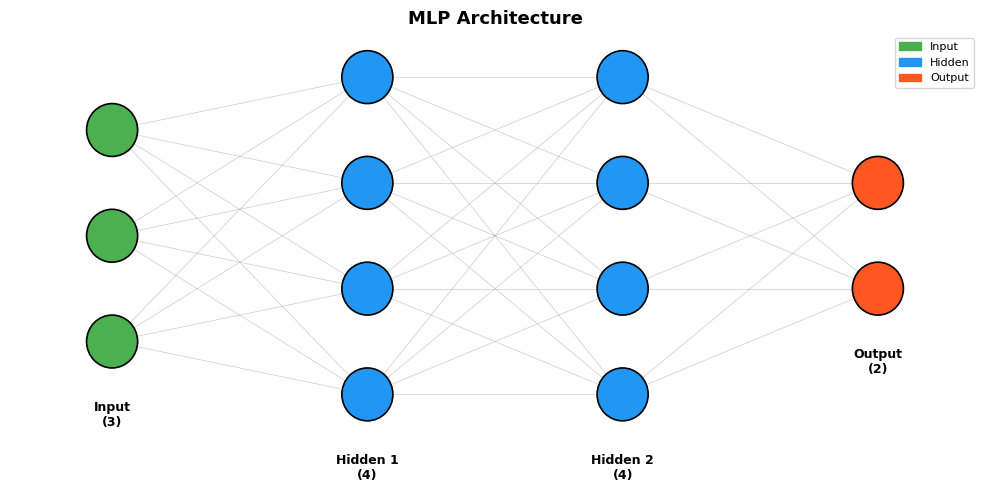

In [3]:
def draw_network(layer_sizes, layer_labels=None, title="MLP Architecture"):
    """Draw a simple MLP diagram.

    Parameters
    ----------
    layer_sizes  : list[int]  – number of neurons per layer (input → output)
    layer_labels : list[str]  – optional label per layer
    """
    fig, ax = plt.subplots(figsize=(2.5 * len(layer_sizes), 5))
    ax.axis('off')

    v_gap = 1.0          # vertical spacing between neurons
    h_gap = 2.5          # horizontal spacing between layers
    radius = 0.25

    # collect neuron positions
    positions = []
    for l_idx, n in enumerate(layer_sizes):
        x = l_idx * h_gap
        y_start = -(n - 1) * v_gap / 2
        positions.append([(x, y_start + i * v_gap) for i in range(n)])

    # draw connections
    for l in range(len(positions) - 1):
        for (x1, y1) in positions[l]:
            for (x2, y2) in positions[l + 1]:
                ax.plot([x1, x2], [y1, y2], 'gray', lw=0.5, alpha=0.4, zorder=0)

    # choose colours per layer
    colours = ['#4CAF50'] + ['#2196F3'] * (len(layer_sizes) - 2) + ['#FF5722']

    # draw neurons
    for l_idx, layer_pos in enumerate(positions):
        for (x, y) in layer_pos:
            circle = plt.Circle((x, y), radius, color=colours[l_idx],
                                 ec='black', lw=1.2, zorder=2)
            ax.add_patch(circle)

    # layer labels
    if layer_labels is None:
        layer_labels = (["Input"] +
                        [f"Hidden {i+1}" for i in range(len(layer_sizes) - 2)] +
                        ["Output"])
    for l_idx, label in enumerate(layer_labels):
        x = l_idx * h_gap
        y_bottom = min(p[1] for p in positions[l_idx]) - v_gap * 0.8
        ax.text(x, y_bottom, f"{label}\n({layer_sizes[l_idx]})",
                ha='center', fontsize=9, fontweight='bold')

    patches = [
        mpatches.Patch(color='#4CAF50', label='Input'),
        mpatches.Patch(color='#2196F3', label='Hidden'),
        mpatches.Patch(color='#FF5722', label='Output'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(-1, (len(layer_sizes) - 1) * h_gap + 1)
    plt.tight_layout()
    plt.show()


# Architecture we will build: 3 inputs → 4 hidden → 4 hidden → 2 outputs
draw_network([3, 4, 4, 2])

## 3. Forward Propagation — The Math

For each layer $l = 1, 2, \dots, L$:

$$
z^{[l]} = W^{[l]}\, a^{[l-1]} + b^{[l]}
$$
$$
a^{[l]} = f^{[l]}\!\left(z^{[l]}\right)
$$

where $a^{[0]} = X$ (the input) and $f^{[l]}$ is the activation function chosen for that layer.

### Why matrix notation?

Suppose we have a batch of $m$ training examples.  
Stacking them into $X \in \mathbb{R}^{n_x \times m}$ lets a single matrix multiplication propagate **all examples at once**.

Matrix notation is useful because it makes complex calculations **compact, fast, and scalable**.

- **Compact representation**:  
  A system of equations like  
  $$
  \begin{aligned}
  2x + 3y &= 5 \\
  4x - y &= 6
  \end{aligned}
  $$
  becomes  
  $$
  \begin{bmatrix}
  2 & 3 \\
  4 & -1
  \end{bmatrix}
  \begin{bmatrix}
  x\\y
  \end{bmatrix}
  =
  \begin{bmatrix}
  5\\6
  \end{bmatrix}
  $$

- **Efficient computation**:  
  Computers (especially GPUs) are optimized for matrix operations, so matrix form runs much faster than doing each equation separately.

- **Clear structure in ML/AI**:  
  In neural networks, instead of computing each neuron one by one, you write:
  $$
  Z = XW + b,\quad A = \sigma(Z)
  $$
  where:
  - $X$: input batch matrix  
  - $W$: weight matrix  
  - $b$: bias vector  
  - $\sigma$: activation function

- **Easy scaling**:  
  For 1 sample with 3 features → 2 neurons:
  $$
  X=
  \begin{bmatrix}
  x_1 & x_2 & x_3
  \end{bmatrix},\ 
  W=
  \begin{bmatrix}
  w_{11} & w_{12}\\
  w_{21} & w_{22}\\
  w_{31} & w_{32}
  \end{bmatrix}
  $$
  then output is one multiplication: $XW$ (size $1 \times 2$).  
  For 1000 samples, same formula works with bigger $X$.


| Quantity | Shape |
|---|---|
| $X$ (input batch) | $(n^{[0]}, m)$ |
| $W^{[l]}$ | $(n^{[l]}, n^{[l-1]})$ |
| $b^{[l]}$ | $(n^{[l]}, 1)$ — broadcast over $m$ |
| $z^{[l]}, a^{[l]}$ | $(n^{[l]}, m)$ |

**Example 1**

Suppose:
$$
X=\begin{bmatrix}1 & 2 & 3\end{bmatrix},\quad
W=\begin{bmatrix}
0.2 & -0.5\\
1.0 & 0.3\\
-0.4 & 0.8
\end{bmatrix},\quad
b=\begin{bmatrix}0.1 & -0.2\end{bmatrix}
$$

Compute pre-activation:
$$
Z = XW + b
$$

First, \(XW\):
$$
\begin{aligned}
z_1' &= 1(0.2)+2(1.0)+3(-0.4)=0.2+2.0-1.2=1.0\\
z_2' &= 1(-0.5)+2(0.3)+3(0.8)=-0.5+0.6+2.4=2.5
\end{aligned}
$$
So,
$$
XW=\begin{bmatrix}1.0 & 2.5\end{bmatrix}
$$

Add bias:
$$
Z=\begin{bmatrix}1.0 & 2.5\end{bmatrix}+\begin{bmatrix}0.1 & -0.2\end{bmatrix}
=\begin{bmatrix}1.1 & 2.3\end{bmatrix}
$$

Apply activation (sigmoid):
$$
A=\sigma(Z)=\begin{bmatrix}\sigma(1.1) & \sigma(2.3)\end{bmatrix}
\approx \begin{bmatrix}0.750 & 0.909\end{bmatrix}
$$

So the 2-neuron layer output is:
$$
\boxed{A\approx\begin{bmatrix}0.750 & 0.909\end{bmatrix}}
$$

**Example 2**
Same layer for a **batch of 3 inputs**.

Use the same parameters:
$$
W=\begin{bmatrix}
0.2 & -0.5\\
1.0 & 0.3\\
-0.4 & 0.8
\end{bmatrix},\quad
b=\begin{bmatrix}0.1 & -0.2\end{bmatrix}
$$

Batch input:
$$
X=\begin{bmatrix}
1 & 2 & 3\\
0 & 1 & -1\\
2 & 0 & 1
\end{bmatrix}
\quad (3\times 3)
$$

Forward pass:
$$
Z = XW + b
$$
Here, \(XW\) gives:
$$
XW=
\begin{bmatrix}
1.0 & 2.5\\
1.4 & -0.5\\
0.0 & -0.2
\end{bmatrix}
$$

Add bias \([0.1,-0.2]\) to every row:
$$
Z=
\begin{bmatrix}
1.1 & 2.3\\
1.5 & -0.7\\
0.1 & -0.4
\end{bmatrix}
$$

Apply sigmoid elementwise:
$$
A=\sigma(Z)\approx
\begin{bmatrix}
0.750 & 0.909\\
0.818 & 0.332\\
0.525 & 0.401
\end{bmatrix}
$$

One matrix equation computes outputs for all 3 samples at once (instead of repeating scalar equations 3 times).  



## 4. Step-by-Step Trace Through a Single Forward Pass

Let's manually propagate **one sample** through a tiny network so every tensor shape is visible.

In [4]:
# ── Activation helpers ──────────────────────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    # Subtract max for numerical stability
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

# ── Tiny network: 3 inputs → 4 hidden (ReLU) → 2 outputs (Softmax) ─────────
n_input, n_hidden, n_output = 3, 4, 2

# Random weight and bias init (small values)
W1 = np.random.randn(n_hidden, n_input)  * 0.1   # (4, 3)
b1 = np.zeros((n_hidden, 1))                      # (4, 1)

W2 = np.random.randn(n_output, n_hidden) * 0.1   # (2, 4)
b2 = np.zeros((n_output, 1))                      # (2, 1)

# Single sample input as a column vector
x = np.array([[0.5], [-1.2], [0.8]])              # (3, 1)

print("════════════════════════════════════════")
print(" LAYER 0 — Input")
print(f"  a[0] shape : {x.shape}")
print(f"  a[0]       : {x.ravel()}")

# ── Layer 1: Hidden ─────────────────────────────────────────────────────────
z1 = W1 @ x + b1          # (4, 3)·(3, 1) + (4, 1) = (4, 1)
a1 = relu(z1)             # (4, 1)

print("\n════════════════════════════════════════")
print(" LAYER 1 — Hidden (ReLU)")
print(f"  W1 shape : {W1.shape}")
print(f"  b1 shape : {b1.shape}")
print(f"  z1 = W1·a0 + b1  → shape {z1.shape}")
print(f"  z1 values        : {z1.ravel().round(4)}")
print(f"  a1 = ReLU(z1)    : {a1.ravel().round(4)}")

# ── Layer 2: Output ─────────────────────────────────────────────────────────
z2 = W2 @ a1 + b2         # (2, 4)·(4, 1) + (2, 1) = (2, 1)
a2 = softmax(z2)          # (2, 1)  → probabilities summing to 1

print("\n════════════════════════════════════════")
print(" LAYER 2 — Output (Softmax)")
print(f"  W2 shape : {W2.shape}")
print(f"  b2 shape : {b2.shape}")
print(f"  z2 = W2·a1 + b2  → shape {z2.shape}")
print(f"  z2 values        : {z2.ravel().round(4)}")
print(f"  ŷ = Softmax(z2)  : {a2.ravel().round(4)}")
print(f"  Sum of ŷ         : {a2.sum():.4f}  (must be 1.0)")

predicted_class = np.argmax(a2)
print(f"\n  Predicted class  : {predicted_class}  (confidence {a2[predicted_class, 0]*100:.1f}%)")

════════════════════════════════════════
 LAYER 0 — Input
  a[0] shape : (3, 1)
  a[0]       : [ 0.5 -1.2  0.8]

════════════════════════════════════════
 LAYER 1 — Hidden (ReLU)
  W1 shape : (4, 3)
  b1 shape : (4, 1)
  z1 = W1·a0 + b1  → shape (4, 1)
  z1 values        : [ 0.0932  0.0855 -0.0507  0.0455]
  a1 = ReLU(z1)    : [0.0932 0.0855 0.     0.0455]

════════════════════════════════════════
 LAYER 2 — Output (Softmax)
  W2 shape : (2, 4)
  b2 shape : (2, 1)
  z2 = W2·a1 + b2  → shape (2, 1)
  z2 values        : [-0.0167 -0.0132]
  ŷ = Softmax(z2)  : [0.4991 0.5009]
  Sum of ŷ         : 1.0000  (must be 1.0)

  Predicted class  : 1  (confidence 50.1%)


## 5. Visualising Activations Layer by Layer

Let's use a small batch of random inputs and plot how the distribution of activations changes at each layer.  
This builds intuition for what "representation learning" means — each layer transforms the data into a new space.

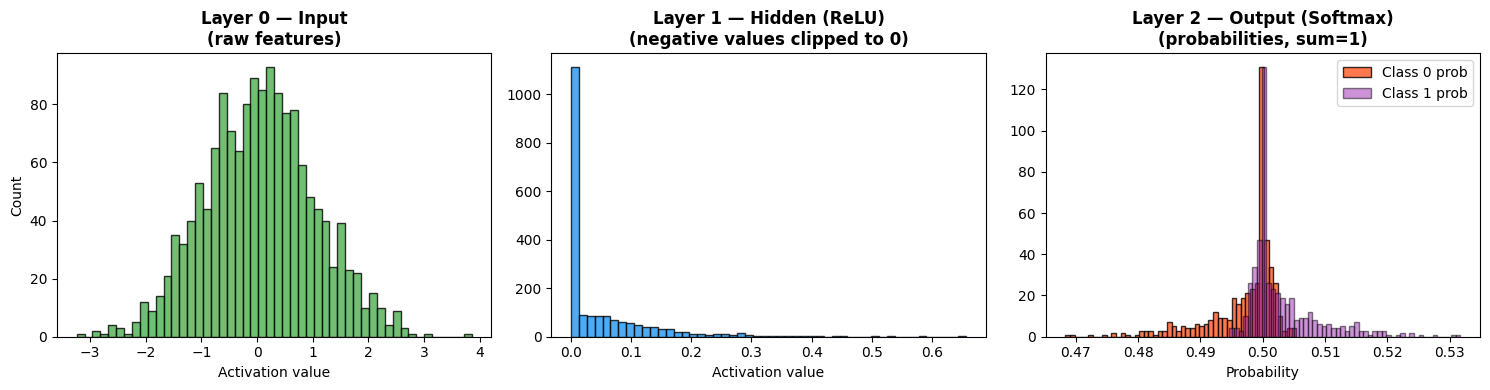

In [5]:
m = 500  # batch size
X_batch = np.random.randn(n_input, m)   # (3, 500)

# Forward pass over the whole batch
Z1_batch = W1 @ X_batch + b1            # (4, 500)
A1_batch = relu(Z1_batch)

Z2_batch = W2 @ A1_batch + b2           # (2, 500)
A2_batch = softmax(Z2_batch)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_batch.ravel(), bins=50, color='#4CAF50', edgecolor='black', alpha=0.8)
axes[0].set_title('Layer 0 — Input\n(raw features)', fontweight='bold')
axes[0].set_xlabel('Activation value')
axes[0].set_ylabel('Count')

axes[1].hist(A1_batch.ravel(), bins=50, color='#2196F3', edgecolor='black', alpha=0.8)
axes[1].set_title('Layer 1 — Hidden (ReLU)\n(negative values clipped to 0)', fontweight='bold')
axes[1].set_xlabel('Activation value')

axes[2].hist(A2_batch[0], bins=50, color='#FF5722', edgecolor='black', alpha=0.8, label='Class 0 prob')
axes[2].hist(A2_batch[1], bins=50, color='#9C27B0', edgecolor='black', alpha=0.5, label='Class 1 prob')
axes[2].set_title('Layer 2 — Output (Softmax)\n(probabilities, sum=1)', fontweight='bold')
axes[2].set_xlabel('Probability')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Generalised MLP Class with Forward Propagation

Now let's build a reusable `MLP` class that accepts any architecture, stores the cache of activations needed later by backpropagation, and exposes a clean `forward()` method.

In [ ]:
class MLP:
    """
    Generalised Multi-Layer Perceptron — forward pass only.

    Parameters
    ----------
    layer_dims  : list[int]  – neuron count per layer, e.g. [4, 8, 8, 3]
    activations : list[str]  – activation per *non-input* layer, e.g. ['relu', 'relu', 'softmax']
    """

    ACTIVATION_FN = {
        'relu':    lambda z: np.maximum(0, z),
        'sigmoid': lambda z: 1 / (1 + np.exp(-z)),
        'tanh':    lambda z: np.tanh(z),
        'softmax': lambda z: (lambda e: e / e.sum(axis=0, keepdims=True))(
                       np.exp(z - z.max(axis=0, keepdims=True))
                   ),
        'linear':  lambda z: z,
    }

    def __init__(self, layer_dims, activations):
        assert len(activations) == len(layer_dims) - 1, (
            "Need one activation per non-input layer."
        )
        self.layer_dims  = layer_dims
        self.activations = activations
        self.params      = {}   # weights & biases
        self.cache       = {}   # z and a per layer  (used by backprop)
        self._init_params()

    # ── Initialisation ────────────────────────────────────────────────────
    def _init_params(self):
        L = len(self.layer_dims)
        for l in range(1, L):
            # He init for ReLU layers, Xavier otherwise
            fan_in = self.layer_dims[l - 1]
            scale  = (np.sqrt(2 / fan_in)
                      if self.activations[l - 1] in ('relu',)
                      else np.sqrt(1 / fan_in))
            self.params[f'W{l}'] = np.random.randn(self.layer_dims[l], fan_in) * scale
            self.params[f'b{l}'] = np.zeros((self.layer_dims[l], 1))

    # ── Forward pass ─────────────────────────────────────────────────────
    def forward(self, X, verbose=False):
        """
        Push X through every layer and return the output activations.

        Parameters
        ----------
        X       : np.ndarray, shape (n_features, m)
        verbose : bool – print shape/stats at each layer
        """
        self.cache['a0'] = X
        a_prev = X
        L = len(self.layer_dims) - 1   # number of layers (excluding input)

        for l in range(1, L + 1):
            W = self.params[f'W{l}']
            b = self.params[f'b{l}']
            fn_name = self.activations[l - 1]
            fn = self.ACTIVATION_FN[fn_name]

            z = W @ a_prev + b
            a = fn(z)

            self.cache[f'z{l}'] = z
            self.cache[f'a{l}'] = a
            a_prev = a

            if verbose:
                print(f"  Layer {l} [{fn_name:8s}]  "
                      f"W:{W.shape}  z:{z.shape}  "
                      f"a_min={a.min():.3f}  a_max={a.max():.3f}")

        return a_prev

    def predict(self, X):
        """Return predicted class labels (column indices with highest probability)."""
        probs = self.forward(X)
        return np.argmax(probs, axis=0)

    def summary(self):
        """Print a compact table of the network architecture."""
        L = len(self.layer_dims) - 1
        total = 0
        print(f"{'Layer':<8} {'Type':<12} {'Input':>8} {'Output':>8} {'Params':>10}")
        print("-" * 50)
        print(f"{'0':<8} {'Input':<12} {'':>8} {str(self.layer_dims[0]):>8} {'':>10}")
        for l in range(1, L + 1):
            n_params = (self.layer_dims[l - 1] * self.layer_dims[l]   # weights
                        + self.layer_dims[l])                          # biases
            total += n_params
            print(f"{l:<8} {self.activations[l-1]:<12} "
                  f"{self.layer_dims[l-1]:>8} {self.layer_dims[l]:>8} {n_params:>10,}")
        print("-" * 50)
        print(f"{'Total trainable parameters':>40}: {total:,}")


# ── Instantiate and inspect ─────────────────────────────────────────────────
mlp = MLP(
    layer_dims  = [4, 8, 8, 3],
    activations = ['relu', 'relu', 'softmax']
)
mlp.summary()

Layer    Type            Input   Output     Params
--------------------------------------------------
0        Input                        4           
1        relu                4        8         40
2        relu                8        8         72
3        softmax             8        3         27
--------------------------------------------------
              Total trainable parameters: 139


## 7. Tracing the Forward Pass with Verbose Output

Let's run one forward pass through the network and inspect each layer's output shape and value range.

In [7]:
m_demo = 6   # 6 sample inputs
X_demo = np.random.randn(4, m_demo)   # 4 features, 6 samples

print("Forward pass (verbose mode)")
print(f"Input shape: {X_demo.shape}")
print()

output = mlp.forward(X_demo, verbose=True)

print(f"\nOutput (ŷ) shape: {output.shape}")
print("Predicted probabilities per sample (columns):\n")

for s in range(m_demo):
    probs = output[:, s]
    cls   = np.argmax(probs)
    print(f"  Sample {s}:  " +
          "  ".join(f"class{i}={p:.3f}" for i, p in enumerate(probs)) +
          f"  → predicted class {cls}")

Forward pass (verbose mode)
Input shape: (4, 6)

  Layer 1 [relu    ]  W:(8, 4)  z:(8, 6)  a_min=0.000  a_max=3.566
  Layer 2 [relu    ]  W:(8, 8)  z:(8, 6)  a_min=0.000  a_max=3.884
  Layer 3 [softmax ]  W:(3, 8)  z:(3, 6)  a_min=0.074  a_max=0.645

Output (ŷ) shape: (3, 6)
Predicted probabilities per sample (columns):

  Sample 0:  class0=0.314  class1=0.425  class2=0.261  → predicted class 1
  Sample 1:  class0=0.241  class1=0.266  class2=0.493  → predicted class 2
  Sample 2:  class0=0.101  class1=0.607  class2=0.292  → predicted class 1
  Sample 3:  class0=0.074  class1=0.560  class2=0.366  → predicted class 1
  Sample 4:  class0=0.303  class1=0.462  class2=0.235  → predicted class 1
  Sample 5:  class0=0.119  class1=0.645  class2=0.236  → predicted class 1


## 8. Deeper Dive — Comparing Weight Initialisations

The way we initialise weights heavily influences how signal travels through a deep network.  
**Zero init** causes all neurons to learn the same thing (symmetry problem).  
**Large random init** leads to exploding or vanishing signals.  
**He / Xavier init** (used above) keeps variance stable across layers.

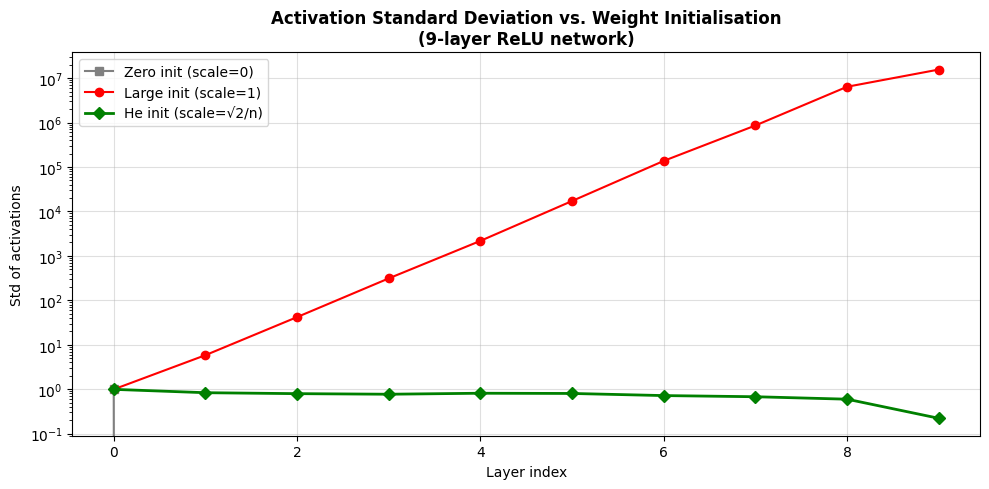

Zero init  — std at last layer: 0.0000
Large init — std at last layer: 15584893.2067
He init    — std at last layer: 0.2212


In [15]:
def manual_forward(X, layer_dims, init_scale, activation_fn=relu):
    """Forward pass with a fixed weight scale — used for init comparison."""
    a = X
    stds = [X.std()]
    for l in range(len(layer_dims) - 1):
        W = np.random.randn(layer_dims[l + 1], layer_dims[l]) * init_scale
        b = np.zeros((layer_dims[l + 1], 1))
        z = W @ a + b
        a = activation_fn(z)
        stds.append(a.std())
    return stds


np.random.seed(0)
deep_dims  = [100, 100, 100, 100, 100, 100, 100, 100, 100, 1]
X_deep     = np.random.randn(100, 256)

stds_zero   = manual_forward(X_deep, deep_dims, init_scale=0.0)
stds_large  = manual_forward(X_deep, deep_dims, init_scale=1.0)
# He init scale = sqrt(2/fan_in)
stds_he     = manual_forward(X_deep, deep_dims, init_scale=np.sqrt(2 / 100))

layers = range(len(deep_dims))
plt.figure(figsize=(10, 5))
plt.plot(layers, stds_zero,  's-', label='Zero init (scale=0)',   color='gray')
plt.plot(layers, stds_large, 'o-', label='Large init (scale=1)',   color='red')
plt.plot(layers, stds_he,    'D-', label='He init (scale=√2/n)',   color='green', lw=2)
plt.xlabel('Layer index')
plt.ylabel('Std of activations')
plt.title('Activation Standard Deviation vs. Weight Initialisation\n(9-layer ReLU network)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Zero init  — std at last layer: {stds_zero[-1]:.4f}")
print(f"Large init — std at last layer: {stds_large[-1]:.4f}")
print(f"He init    — std at last layer: {stds_he[-1]:.4f}")

## 9. End-to-End Example — Iris Dataset

We now apply our `MLP` to the classic Iris dataset (3 classes, 4 features).  
Note: weights are **random** — no training yet. We are only testing that forward propagation works correctly end-to-end and that output probabilities are valid.

In [9]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_raw, y_true = iris.data, iris.target   # (150, 4), (150,)

# Normalise features (important — activations can explode on raw values)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw).T   # shape (4, 150) — features × samples

print("Dataset info")
print(f"  Samples    : {X_norm.shape[1]}")
print(f"  Features   : {X_norm.shape[0]}")
print(f"  Classes    : {iris.target_names.tolist()}")
print(f"  X shape    : {X_norm.shape}   (features × samples)")

Dataset info
  Samples    : 150
  Features   : 4
  Classes    : ['setosa', 'versicolor', 'virginica']
  X shape    : (4, 150)   (features × samples)


In [10]:
# Build network:  4 inputs → 16 hidden (ReLU) → 8 hidden (ReLU) → 3 outputs (Softmax)
iris_mlp = MLP(
    layer_dims  = [4, 16, 8, 3],
    activations = ['relu', 'relu', 'softmax']
)
iris_mlp.summary()

Layer    Type            Input   Output     Params
--------------------------------------------------
0        Input                        4           
1        relu                4       16         80
2        relu               16        8        136
3        softmax             8        3         27
--------------------------------------------------
              Total trainable parameters: 243


In [11]:
# Forward propagation on the entire dataset
probs   = iris_mlp.forward(X_norm)     # (3, 150)
y_pred  = iris_mlp.predict(X_norm)     # (150,)

accuracy = (y_pred == y_true).mean() * 100

print(f"Output probability matrix shape : {probs.shape}")
print(f"Probability column sums (first 5): {probs.sum(axis=0)[:5].round(6)}")
print(f"\nAccuracy with random weights     : {accuracy:.1f}%")
print("  (Expected ~33 % — purely random, no training yet)")

Output probability matrix shape : (3, 150)
Probability column sums (first 5): [1. 1. 1. 1. 1.]

Accuracy with random weights     : 39.3%
  (Expected ~33 % — purely random, no training yet)


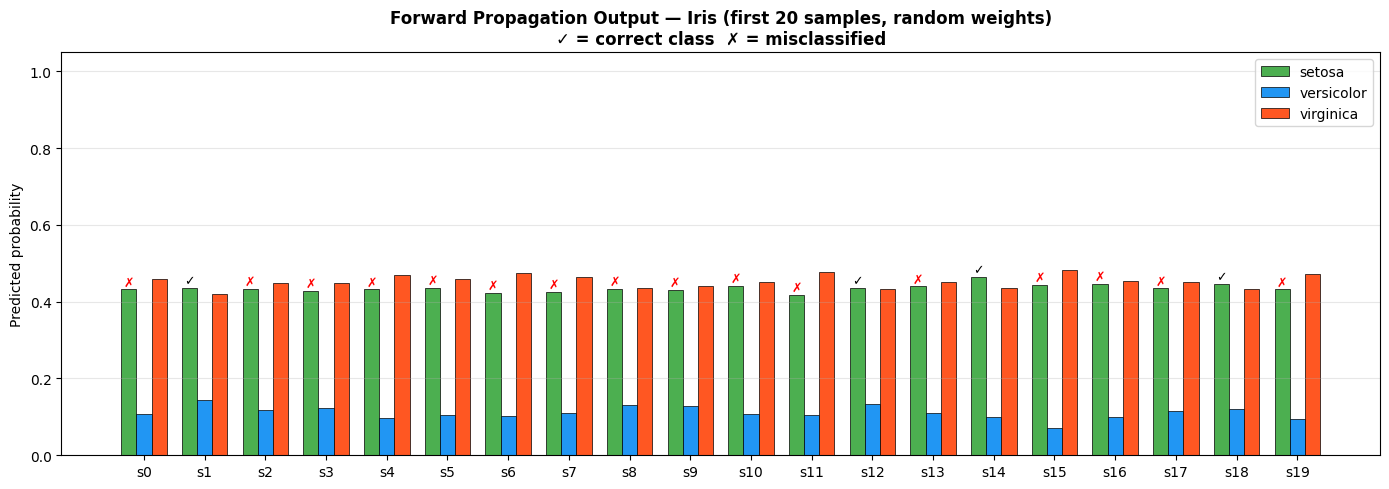

In [12]:
# Visualise predicted probabilities for the first 20 samples
n_show = 20
bar_width = 0.25
x_pos = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#4CAF50', '#2196F3', '#FF5722']
for cls in range(3):
    ax.bar(x_pos + cls * bar_width,
           probs[cls, :n_show],
           width=bar_width,
           label=f'{iris.target_names[cls]}',
           color=colors[cls], edgecolor='black', linewidth=0.5)

# Mark the true class
for i in range(n_show):
    true_cls = y_true[i]
    ax.annotate('✓' if y_pred[i] == true_cls else '✗',
                xy=(i + true_cls * bar_width, probs[true_cls, i] + 0.01),
                fontsize=9, ha='center',
                color='black' if y_pred[i] == true_cls else 'red')

ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels([f"s{i}" for i in range(n_show)])
ax.set_ylabel('Predicted probability')
ax.set_title('Forward Propagation Output — Iris (first 20 samples, random weights)\n'
             '✓ = correct class  ✗ = misclassified', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Cross-Entropy Loss — Measuring Prediction Quality

Now that we have probabilities $\hat{y}$, we can measure how wrong the network is using **categorical cross-entropy**:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \hat{y}_k^{(i)}
$$

where $y_k^{(i)}$ is the one-hot target for sample $i$ and class $k$.  
Loss = **0** means perfect prediction; loss → **∞** means total confidence in the wrong class.

This loss value is what backpropagation will minimise in the next notebook.

In [ ]:
def cross_entropy_loss(probs, y_true):
    """
    Categorical cross-entropy loss.

    Parameters
    ----------
    probs  : np.ndarray, shape (K, m)  – softmax output
    y_true : np.ndarray, shape (m,)    – integer class labels

    Returns
    -------
    float – mean loss over the batch
    """
    m = probs.shape[1]
    K = probs.shape[0]

    # One-hot encode y_true → (K, m)
    Y_onehot = np.eye(K)[:, y_true]   # slick vectorised one-hot

    # Clip probabilities to avoid log(0)
    probs_clipped = np.clip(probs, 1e-12, 1 - 1e-12)

    loss = -np.sum(Y_onehot * np.log(probs_clipped)) / m
    return loss


loss = cross_entropy_loss(probs, y_true)
print(f"Cross-entropy loss (random weights): {loss:.4f}")
print(f"Baseline loss (uniform random 33%): {-np.log(1/3):.4f}")
print()
print("Interpretation:")
print("  A loss close to ln(3) ≈ 1.099 means the network is guessing uniformly.")
print("  After training (backpropagation) the loss should drop significantly.")

Cross-entropy loss (random weights): 0.9678
Baseline loss (uniform random 33%): 1.0986

Interpretation:
  A loss close to ln(3) ≈ 1.099 means the network is guessing uniformly.
  After training (backpropagation) the loss should drop significantly.


## Summary

| Concept | Key takeaway |
|---|---|
| **Layer** | Applies $a = f(Wx + b)$; each layer transforms its input into a new representation |
| **Weight matrix $W^{[l]}$** | Shape $(n^{[l]}, n^{[l-1]})$; one row per neuron in the current layer |
| **Bias $b^{[l]}$** | Shifts the activation; broadcast over all samples in a batch |
| **Pre-activation $z^{[l]}$** | Linear combination before activation |
| **Post-activation $a^{[l]}$** | What leaves the layer and enters the next one |
| **Softmax** | Converts raw scores into a proper probability distribution (sums to 1) |
| **He init** | Keeps activation variance stable in deep ReLU networks |
| **Cross-entropy** | Quantifies how wrong the probability predictions are |
